#  Análisis Exploratorio de Datos (EDA) - Airbnb CDMX

En esta fase analizaremos la distribución del mercado, identificando zonas de alto valor y correlaciones entre variables.

In [ ]:
import pandas as pd
import sys
import os

# Configuración de rutas
sys.path.append(os.path.abspath('../src'))
from visualization import (
    plot_price_boxplot, 
    plot_scatter_reviews_price, 
    plot_scatter_nights_price, 
    plot_corr_heatmap,
    save_fig
)

### 1. Carga de Datos

Utilizamos el dataset procesado que generamos anteriormente.

In [ ]:
df = pd.read_csv('../data/processed/listings_clean.csv')
print(f"Dataset cargado con {len(df)} registros.")

### 2. Precio por Barrio (Top 10)

Ajustado al percentil 95 para mejorar la visibilidad.

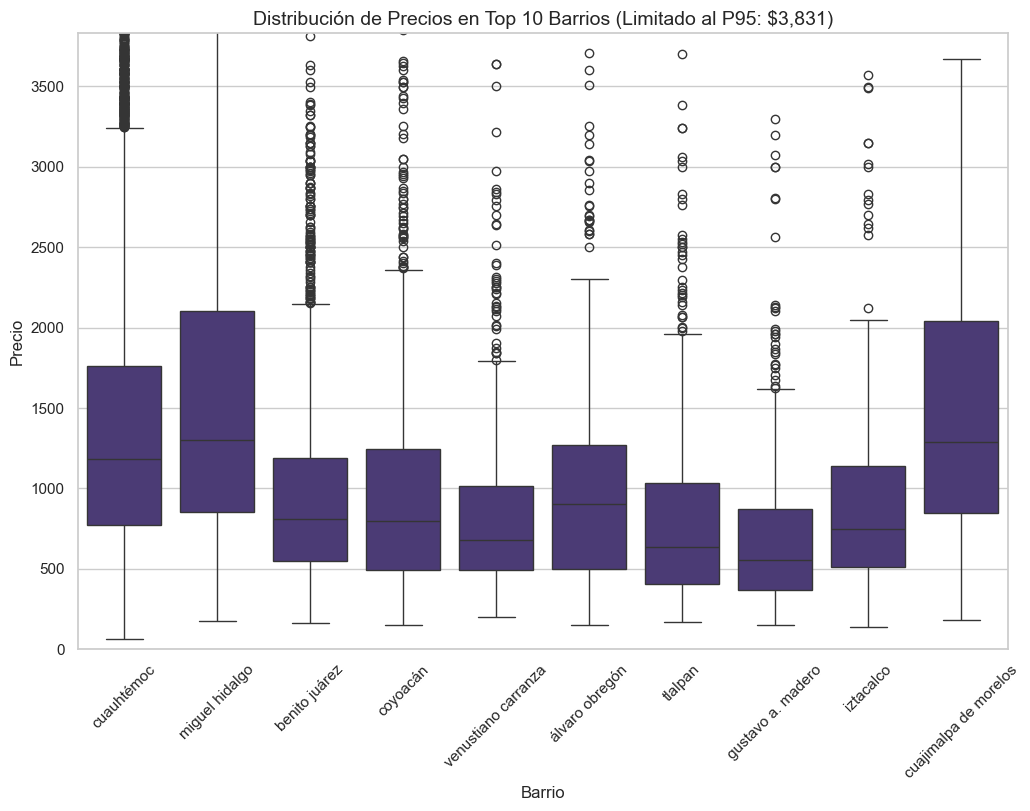

[visualization] Figura guardada en: C:\Users\Acer\Documents\Proyecto1\Airbnb\reports\figures\01_precio_por_barrio_p95.png


<Figure size 1000x600 with 0 Axes>

In [12]:
plot_price_boxplot(df, group_col='neighbourhood', use_p95=True)
save_fig("01_precio_por_barrio_p95")

### 3. Precio por Tipo de Habitación

¿Qué tanta diferencia de precio hay entre una casa completa y una habitación compartida?

In [ ]:
plot_price_boxplot(df, group_col='room_type', use_p95=True)
save_fig("05_precio_por_tipo_habitacion")

### 4. Reseñas vs Precio

In [ ]:
plot_scatter_reviews_price(df)
save_fig("02_reviews_vs_price")

### 5. Mínimo de Noches vs Precio

In [ ]:
plot_scatter_nights_price(df)
save_fig("03_nights_vs_price")

### 6. Correlaciones Generales (Incluyendo Room Type)

In [ ]:
plot_corr_heatmap(df, include_categorical=['room_type'])
save_fig("04_heatmap_correlaciones_extendido")

##  Hallazgos de Negocio

- **Hallazgo 1: Desacople Precio-Popularidad** → El número de reseñas tiene una correlación lineal casi nula con el precio. Esto implica que para un usuario en CDMX, un precio alto no garantiza un alojamiento "probado" por muchos, y es posible encontrar propiedades muy populares (muchas reseñas) sin que su precio se dispare.

- **Hallazgo 2: Escasez en Segmento Hotelero** → El tipo de habitación `hotel room` solo cuenta con 57 listados frente a los >15,000 de casas completas. Esto implica que las conclusiones sobre este segmento no son estadísticamente confiables; deben excluirse del modelo predictivo o tratarse con extrema cautela.

- **Hallazgo 3: Segmentación Geográfica de Prestigio** → **Miguel Hidalgo** (donde están Polanco y Lomas) y **Cuajimalpa** (donde está Santa Fe) tienen las medianas de precio más altas, mientras que **Gustavo A. Madero e Iztapalapa** tienen las más bajas. Esto implica una fuerte segregación del mercado basada en el nivel socioeconómico de la zona (Oeste corporativo/lujoso vs Norte/Este residencial-industrial).